# TransFit Tutorial: Fitting the Example Data

This notebook fits the two example data files shipped with TransFit:

- `sn1993j_lbol.txt`: bolometric luminosity data.
- `sn2007gr.csv`: multi-band `B/V/R/I` photometry.

The examples follow the public datasets used in the official TransFit paper. Both examples use the `nickel` model and run `emcee` with `nsteps=5000`.

In [1]:
from pathlib import Path
import sys

# Make the notebook work both from the repository root and from examples/.
CWD = Path.cwd().resolve()
if (CWD / "transfit").is_dir():
    REPO_ROOT = CWD
elif (CWD.parent / "transfit").is_dir():
    REPO_ROOT = CWD.parent
else:
    raise RuntimeError("Could not locate the local TransFit repository root.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import transfit as tf

DATA_DIR = REPO_ROOT / "examples" / "data"
OUT_DIR = REPO_ROOT / "mcmc_out"
OUT_DIR.mkdir(exist_ok=True)
print("Using TransFit from:", Path(tf.__file__).resolve().relative_to(REPO_ROOT).as_posix())

Using TransFit from: transfit/__init__.py


## 1. Load the example data

In [2]:
def load_sn1993j_bolometric():
    arr = np.loadtxt(DATA_DIR / "sn1993j_lbol.txt", comments="#")
    t_days = arr[:, 0] - np.nanmin(arr[:, 0])
    return tf.BolometricData(
        t_days=t_days,
        y=arr[:, 1],
        yerr=arr[:, 2],
    )


def load_sn2007gr_multiband():
    df = pd.read_csv(DATA_DIR / "sn2007gr.csv")
    phase = np.asarray(df["Phase"], float)
    t0 = float(np.nanmin(phase))

    mag_cols = {
        "B": ("Bmag", "e_Bmag"),
        "V": ("Vmag", "e_Vmag"),
        "R": ("Rmag", "e_Rmag"),
        "I": ("Imag", "e_Imag"),
    }

    t_days, bands, y, yerr = [], [], [], []
    for band, (mcol, ecol) in mag_cols.items():
        mag = pd.to_numeric(df[mcol], errors="coerce").to_numpy(float)
        err = pd.to_numeric(df[ecol], errors="coerce").to_numpy(float)
        good = np.isfinite(phase) & np.isfinite(mag) & np.isfinite(err) & (err > 0.0)
        t_days.extend((phase[good] - t0).tolist())
        y.extend(mag[good].tolist())
        yerr.extend(err[good].tolist())
        bands.extend([band] * int(np.sum(good)))

    order = np.argsort(np.asarray(t_days, float))
    return tf.MultiBandData(
        t_days=np.asarray(t_days, float)[order],
        band=np.asarray(bands, dtype=object)[order],
        y=np.asarray(y, float)[order],
        yerr=np.asarray(yerr, float)[order],
    )


def trim_multiband_time(data, t_max_days):
    keep = np.asarray(data.t_days, float) <= float(t_max_days)
    return tf.MultiBandData(
        t_days=np.asarray(data.t_days, float)[keep],
        band=np.asarray(data.band, dtype=object)[keep],
        y=np.asarray(data.y, float)[keep],
        yerr=np.asarray(data.yerr, float)[keep],
    )


bol_data = load_sn1993j_bolometric()
mb_data = load_sn2007gr_multiband()
mb_fit_data = trim_multiband_time(mb_data, 90.0)

print(f"SN1993J bolometric points: {bol_data.t_days.size}")
print(f"SN2007gr multiband points: {mb_data.t_days.size}, bands: {mb_data.bands}")
print(f"SN2007gr fit points with t <= 90 d: {mb_fit_data.t_days.size}, bands: {mb_fit_data.bands}")

SN1993J bolometric points: 89
SN2007gr multiband points: 307, bands: ['B', 'I', 'R', 'V']
SN2007gr fit points with t <= 90 d: 230, bands: ['B', 'I', 'R', 'V']


## 2. Fit `sn1993j_lbol.txt` with `emcee`

All bolometric points are included in the likelihood. The example uses a small fixed `sigma_int` term because the tabulated bolometric errors are much smaller than the model/data systematics, especially during the early cooling phase.

In [3]:
print(tf.model_param_names("nickel"))

bol_sampler_kwargs = {
    "nwalkers": 48,
    "nsteps": 5000,
    "burnin": 300,
    "thin": 10,
    "seed": 123,
    "progress": True,
    "robust_init": False,
}

bol_priors = {
    "M_ej": (0.3, 8.0),
    "v_ej": (0.2, 4.0),
    "E_Th_in": (0.01, 80.0),
    "M_ni": ("log10", -3.0, -0.2),
    "R_0": (10.0, 2000.0),
    "f_ni": (0.02, 0.9),
    "kappa": (0.02, 0.4),
    "kappa_gamma": (0.003, 0.2),
    "t_shift": (0.0, 15.0),
}

bol_fixed = {
    "sigma_int": 0.08,
}

res_bol = tf.fit_bol(
    data=bol_data,
    model="nickel",
    z=0.001728,
    priors=bol_priors,
    fixed=bol_fixed,
    sampler="emcee",
    sampler_kwargs=bol_sampler_kwargs,
)

print("Bolometric fit samples:", res_bol.samples.shape)
print("Bolometric best log_prob:", res_bol.best_log_prob)
res_bol.best_params_raw

['M_ej', 'v_ej', 'E_Th_in', 'M_ni', 'R_0', 'f_ni', 'kappa', 'kappa_gamma', 'T_floor']


100%|██████████| 5000/5000 [04:44<00:00, 17.58it/s]


Bolometric fit samples: (24000, 9)
Bolometric best log_prob: -8454.742512600826


{'M_ej': 1.3468760510739042,
 'v_ej': 0.7699574370642042,
 'E_Th_in': 4.523889456230659,
 'M_ni': 0.09297742757025906,
 'R_0': 271.20398552747815,
 'f_ni': 0.4559059756667398,
 'kappa': 0.10227556723514937,
 'kappa_gamma': 0.05024615367183008,
 't_shift': 0.2534568104354886,
 'sigma_int': 0.08}

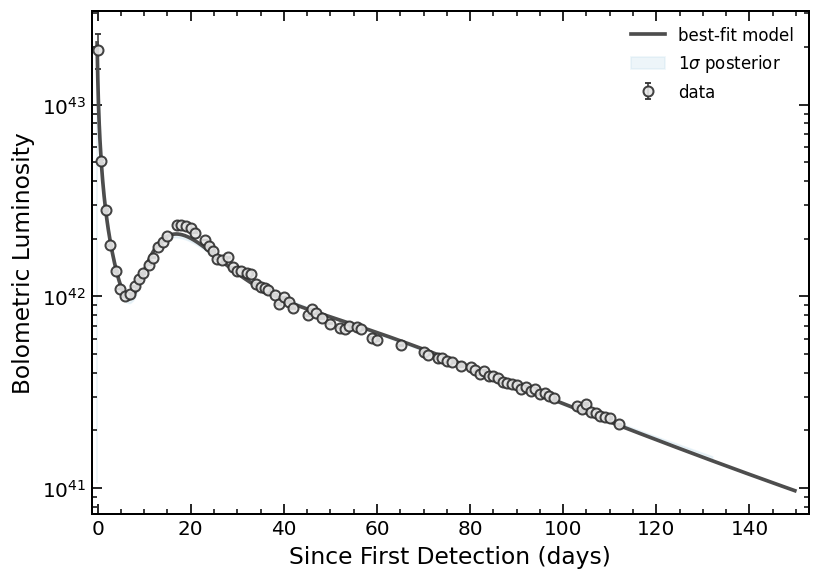

In [4]:
fig_bol = tf.plot.fit_bol(
    res_bol,
    data=bol_data,
    show_1sigma=True,
    n_draws=100,
    n_t=500,
    t_pad=20.0,
)
fig_bol

## 3. Fit `sn2007gr.csv` with `emcee`

For SN2007gr, the tutorial fits the first 90 days of `B/V/R/I` photometry and then draws a paper-style offset light-curve plot. The example below uses built-in Johnson-Cousins filter IDs. For custom mono filters, replace a filter value with an effective-wavelength dictionary such as `{"lambda_eff_A": 4770.0}`; add `vega_zero_point_jy` when using `mag_system="vega"`.

In [18]:
multiband_sampler_kwargs = {
    "nwalkers": 48,
    "nsteps": 5000,
    "burnin": 300,
    "thin": 10,
    "seed": 456,
    "progress": True,
}

multiband_priors = {
    "M_ej": (1.0, 10.0),
    "v_ej": (0.2, 4.0),
    "M_ni": (0.01, 1.0),
    "f_ni": (0.01, 0.9),
    "kappa": (0.01, 0.30),
    "kappa_gamma": (0.01, 1.0),
    "T_floor": (3000.0, 6000.0),
    "t_shift": (0.0, 15.0),
}

multiband_fixed = {
    "E_Th_in": 0,
    "R_0": 10,
}

filters = {
    "B": "johnson_cousins.B",
    "V": "johnson_cousins.V",
    "R": "johnson_cousins.R",
    "I": "johnson_cousins.I",
}

res_mb = tf.fit_multiband(
    data=mb_fit_data,
    model="nickel",
    z=0.001728,
    filters=filters,
    y_kind="mag",
    mag_system="vega",
    priors=multiband_priors,
    fixed=multiband_fixed,
    sampler="emcee",
    sampler_kwargs=multiband_sampler_kwargs,
)

print("Multi-band fit samples:", res_mb.samples.shape)
print("Multi-band best log_prob:", res_mb.best_log_prob)
res_mb.best_params_raw

100%|██████████| 5000/5000 [05:10<00:00, 16.12it/s]


Multi-band fit samples: (24000, 8)
Multi-band best log_prob: -3390.105127851218


{'M_ej': 1.0063073114209486,
 'v_ej': 0.3141635917857643,
 'E_Th_in': 0.0,
 'M_ni': 0.04730935603984591,
 'R_0': 10.0,
 'f_ni': 0.15545214341595334,
 'kappa': 0.032060117315616844,
 'kappa_gamma': 0.010035062264591601,
 'T_floor': 4358.805510657425,
 't_shift': 10.229105576431923}

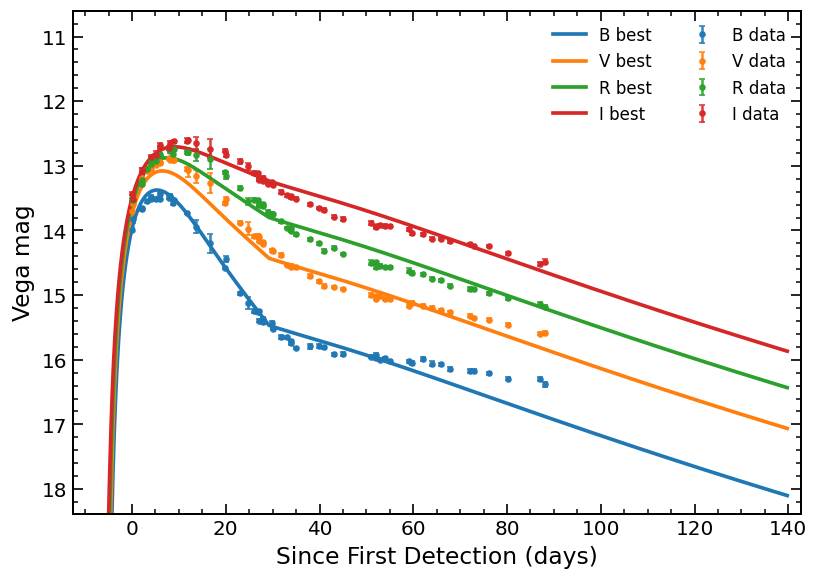

In [19]:
fig_mb = tf.plot.fit_multiband(
    res_mb,
    data=mb_fit_data,
    n_draws=100,
    n_t=300,
    t_pad=20.0,
)
fig_mb

## 4. Save the results

In [20]:
bol_path = tf.save(res_bol, OUT_DIR / "tutorial_sn1993j_bol_emcee5000.npz")
mb_path = tf.save(res_mb, OUT_DIR / "tutorial_sn2007gr_multiband_emcee5000.npz")

print("Saved bolometric result:", Path(bol_path).resolve().relative_to(REPO_ROOT).as_posix())
print("Saved multi-band result:", Path(mb_path).resolve().relative_to(REPO_ROOT).as_posix())
print("Loaded bolometric samples:", tf.load(bol_path)["samples"].shape)
print("Loaded multi-band samples:", tf.load(mb_path)["samples"].shape)

Saved bolometric result: mcmc_out/tutorial_sn1993j_bol_emcee5000.npz
Saved multi-band result: mcmc_out/tutorial_sn2007gr_multiband_emcee5000.npz
Loaded bolometric samples: (24000, 9)
Loaded multi-band samples: (24000, 8)


## 5. Plot best-fit models manually

The default plotting API is convenient, but you can also draw the fitted model yourself: read `best_fit`, pass its physical parameters to a forward model, and plot the returned light curve.

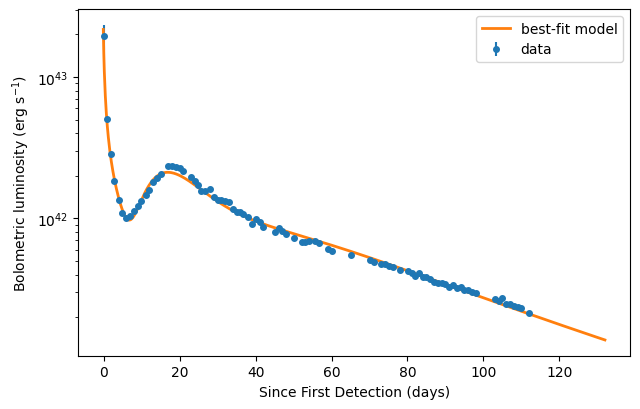

In [21]:
bol_params = dict(res_bol.best_fit["params"])
t_shift_bol = bol_params.pop("t_shift", 0.0)
bol_params.pop("sigma_int", None)

lc_bol = tf.lightcurve_bol(
    model="nickel",
    params=bol_params,
    z=0.001728,
    t_max_days=max(120.0, float(np.nanmax(bol_data.t_days)) + t_shift_bol + 20.0),
)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(bol_data.t_days, bol_data.y, yerr=bol_data.yerr, fmt="o", ms=4, label="data")
ax.plot(lc_bol.t_days - t_shift_bol, lc_bol.Lbol, lw=2.0, label="best-fit model")
ax.set_yscale("log")
ax.set_xlabel("Since First Detection (days)")
ax.set_ylabel("Bolometric luminosity (erg s$^{-1}$)")
ax.legend()
fig.tight_layout()
fig

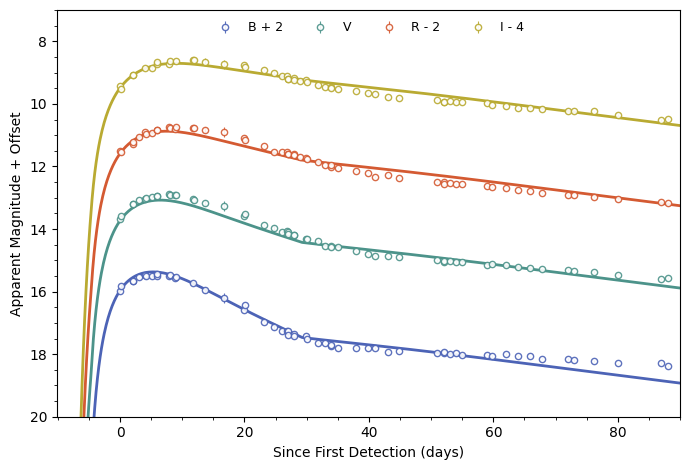

In [29]:
mb_params = dict(res_mb.best_fit["params"])
t_shift_mb = mb_params.pop("t_shift", 0.0)
mb_params.pop("sigma_int", None)

bands_to_plot = [band for band in ["B", "V", "R", "I"] if band in set(mb_fit_data.bands)]
lc_mb = tf.lightcurve_multiband(
    model="nickel",
    params=mb_params,
    z=0.001728,
    filters=filters,
    bands=bands_to_plot,
    y_kind="mag",
    mag_system="vega",
    t_max_days=max(100.0, float(np.nanmax(mb_fit_data.t_days)) + t_shift_mb + 10.0),
)

band_colors = {
    "B": "#4C63B6",
    "V": "#4C938A",
    "R": "#D45A32",
    "I": "#B9AA32",
}
offsets = {"B": 2.0, "V": 0.0, "R": -2.0, "I": -4.0}
x_model = lc_mb.t_days - t_shift_mb
all_y = []

fig, ax = plt.subplots(figsize=(7.0, 4.8))
for band in bands_to_plot:
    color = band_colors[band]
    offset = offsets[band]
    data_mask = mb_fit_data.band == band
    y_data = mb_fit_data.y[data_mask] + offset
    yerr_data = mb_fit_data.yerr[data_mask]
    y_model = lc_mb.y[band] + offset
    sigma = max(0.08, float(np.nanmedian(yerr_data)))
    label = band if offset == 0.0 else f"{band} {'+' if offset > 0 else '-'} {abs(offset):g}"

    ax.errorbar(
        mb_fit_data.t_days[data_mask],
        y_data,
        yerr=yerr_data,
        fmt="o",
        ms=4.5,
        mfc="white",
        mec=color,
        mew=1.0,
        ecolor=color,
        elinewidth=0.8,
        alpha=0.9,
        linestyle="none",
        label=label,
    )
    ax.plot(x_model, y_model, color=color, lw=2.0)
    all_y.extend(y_data[np.isfinite(y_data)].tolist())
    all_y.extend(y_model[np.isfinite(y_model)].tolist())

ax.set_xlim(min(-5.0, float(np.nanmin(x_model))), 90.0)
ax.set_ylim(20, 7)

ax.set_xlabel("Since First Detection (days)")
ax.set_ylabel("Apparent Magnitude + Offset")
ax.minorticks_on()
ax.legend(ncol=4, loc="upper center", frameon=False, fontsize=9)
fig.tight_layout()
fig

## 6. Corner plot

A corner plot only needs a TransFit result object. You can pass the object returned by `tf.fit_*`, or load a saved `.npz` result and pass the loaded dictionary.

In [ ]:
fig_corner = tf.plot.corner(res_mb, max_points=5000)
fig_corner

In [ ]:
loaded_mb = tf.load(mb_path)
fig_corner_loaded = tf.plot.corner(loaded_mb, max_points=5000)
fig_corner_loaded